# 15. GraphRAG - 基于图的知识检索

**复杂度:** ⭐⭐⭐⭐⭐

## 概述

**GraphRAG** 是 Microsoft Research 提出的一种 RAG 方法。它不只依赖向量相似度，而是把知识组织成图结构，从而支持：
- 跨关系的多跳推理
- 以实体为中心的检索
- 基于社区的摘要生成
- 感知关系结构的上下文构建

### 问题

传统向量 RAG 在以下场景里往往不够好：
- **多跳问题**：需要连续跟踪多个实体之间的联系
- **关系查询**：需要直接回答“X 和 Y 怎么相关”
- **实体消歧**：同名但不同对象
- **结构化知识**：需要理解概念之间的网络关系

### 解决方案

GraphRAG 会构建一张**知识图谱**：
```
[实体] --关系--> [实体]
```

**示例：**
```
LangChain --created_by--> Harrison Chase
LangChain --includes--> LCEL
LCEL --is_a--> Framework Component
LCEL --enables--> Chain Building
```

### 流程

```
文档 → 实体抽取 → 关系抽取
    → 图构建 → 社区发现
    → 图索引 → 查询处理
    → 图遍历 → 答案生成
```

### 核心概念

1. **实体**：人、组织、概念、技术
2. **关系**：实体之间的连接方式
3. **社区**：具有强关联的实体簇
4. **多跳**：沿着图中路径连续推理
5. **子图**：完整图中与问题相关的部分

### GraphRAG 的亮点

- **全局查询**：利用社区摘要
- **局部查询**：从特定实体出发做图遍历
- **层级社区**：多层次聚类结构
- **节点嵌入**：为图节点建立向量表示

### 何时使用

**适合：**
- 复杂知识领域
- 多跳推理
- 关系密集型内容
- 以实体为中心的问题
- 需要可解释路径的检索

**不太适合：**
- 简单文档检索
- 实时应用（建索引较慢）
- 关系信息不明确的未结构化文本

### 权衡

**优点：**
- 更擅长多跳推理
- 能显式理解实体关系
- 对复杂查询更友好
- 推理路径更容易解释

**缺点：**
- 索引构建很慢
- LLM 调用成本高
- 实现与运维复杂度高
- 图存储有额外开销

---

## 实现

本 notebook 会构建一个简化版 GraphRAG 系统，但会覆盖其核心组件。


## 1. 设置与导入


In [1]:
import sys
import json
import time
from pathlib import Path
from typing import List, Dict, Any
from collections import defaultdict

# Add parent directory to path for imports
sys.path.append(str(Path("../..").resolve()))

import networkx as nx
import matplotlib.pyplot as plt
from shared.config import create_chat_model, create_embeddings, DEFAULT_MODEL, DEFAULT_TEMPERATURE, DEFAULT_VISION_MODEL
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_community.vectorstores import FAISS

from shared.config import (
    verify_api_key,
    DEFAULT_MODEL,
    DEFAULT_TEMPERATURE,
    HF_EMBEDDING_MODEL,
    VECTOR_STORE_DIR,
)
from shared.loaders import load_and_split
from shared.prompts import (
    ENTITY_EXTRACTION_PROMPT,
    RELATIONSHIP_EXTRACTION_PROMPT,
    ENTITY_DISAMBIGUATION_PROMPT,
    GRAPH_SUMMARIZATION_PROMPT,
    GRAPHRAG_ANSWER_PROMPT,
)
from shared.utils import (
    print_section_header,
    load_vector_store,
    save_vector_store,
)

# Verify API key
verify_api_key()

print("✓ All imports successful")
print(f"✓ Using model: {DEFAULT_MODEL}")
print(f"✓ Using embeddings: {HF_EMBEDDING_MODEL}")
print(f"✓ NetworkX version: {nx.__version__}")

OK deepseek API key: LOADED
  Preview: sk-0501...20ae
  Base URL: https://api.deepseek.com
✓ All imports successful
✓ Using model: deepseek-v4-flash
✓ Using embeddings: sentence-transformers/all-MiniLM-L6-v2
✓ NetworkX version: 3.6.1


## 2. 加载文档


In [2]:
print_section_header("Loading Documents")

# Load documents (returns tuple: original_docs, chunks)
_, docs = load_and_split(
    chunk_size=1500,  # Larger chunks for better entity extraction
    chunk_overlap=200,
)

# Use first 10 docs for demo (full corpus would take too long)
docs_sample = docs[:10]

print(f"\n✓ Loaded {len(docs_sample)} documents for GraphRAG")
print(f"✓ Average chunk size: {sum(len(d.page_content) for d in docs_sample) / len(docs_sample):.0f} chars")

print("\nNote: Using subset for demo. Production would process full corpus.")


LOADING DOCUMENTS

Loading 4 documents from web...
  - https://python.langchain.com/docs/use_cases/question_answering/
  - https://python.langchain.com/docs/modules/data_connection/retrievers/
  - https://python.langchain.com/docs/modules/model_io/llms/
  - https://python.langchain.com/docs/use_cases/chatbots/
✓ Loaded 4 documents
✓ Added custom metadata to all documents
Splitting documents...
  - Chunk size: 1500
  - Chunk overlap: 200
✓ Created 108 chunks

  Sample chunk:
    - Length: 1418 chars
    - Source: https://python.langchain.com/docs/use_cases/question_answering/
    - Preview: Build a RAG agent with LangChain - Docs by LangChainSkip to main contentJoin us May 13th & May 14th at Interrupt, the Agent Conference by LangChain. B...

✓ Loaded 10 documents for GraphRAG
✓ Average chunk size: 1139 chars

Note: Using subset for demo. Production would process full corpus.


## 3. 抽取实体

第一步：识别文档中的关键实体。


In [3]:
print_section_header("Extracting Entities")

# Initialize LLM with configured temperature
llm = create_chat_model(
    model=DEFAULT_MODEL,
    temperature=DEFAULT_TEMPERATURE,  # Use config value for consistency
)

# Entity extraction chain
entity_chain = ENTITY_EXTRACTION_PROMPT | llm | StrOutputParser()

all_entities = []
doc_entities_map = {}  # Map doc to its entities

print("\nExtracting entities from documents...")
print("(This may take a few minutes)\n")

for i, doc in enumerate(docs_sample, 1):
    print(f"  Processing document {i}/{len(docs_sample)}...")
    
    try:
        # Extract entities
        result = entity_chain.invoke({"text": doc.page_content})
        
        # Parse JSON response
        # Remove markdown formatting if present
        result_clean = result.replace("```json", "").replace("```", "").strip()
        entities = json.loads(result_clean)
        
        # Store entities
        doc_entities_map[i] = entities
        all_entities.extend(entities)
        
        print(f"    → Found {len(entities)} entities")
        
    except json.JSONDecodeError as e:
        print(f"    → JSON parse error: {e}")
        doc_entities_map[i] = []
    
    # Rate limiting
    if i < len(docs_sample):
        time.sleep(0.5)

print(f"\n✓ Extracted {len(all_entities)} total entities")

# Show examples
print("\n" + "=" * 80)
print("Example entities:")
print("=" * 80)
for entity in all_entities[:5]:
    print(f"\n• {entity.get('name', 'N/A')}")
    print(f"  Type: {entity.get('type', 'N/A')}")
    print(f"  Description: {entity.get('description', 'N/A')[:100]}...")


EXTRACTING ENTITIES



langchain-openai injected a custom httpx transport to apply `http_socket_options`, which disables httpx's proxy auto-detection (system proxy configuration detected). Set `LANGCHAIN_OPENAI_TCP_KEEPALIVE=0` or pass `http_socket_options=()` to restore default proxy behavior, or supply `openai_proxy` / your own `http_client` / `http_async_client` to take full control.



Extracting entities from documents...
(This may take a few minutes)

  Processing document 1/10...
    → Found 7 entities
  Processing document 2/10...
    → Found 2 entities
  Processing document 3/10...
    → Found 8 entities
  Processing document 4/10...
    → Found 13 entities
  Processing document 5/10...
    → Found 6 entities
  Processing document 6/10...
    → Found 5 entities
  Processing document 7/10...
    → Found 11 entities
  Processing document 8/10...
    → Found 10 entities
  Processing document 9/10...
    → Found 26 entities
  Processing document 10/10...
    → Found 25 entities

✓ Extracted 113 total entities

Example entities:

• LangChain
  Type: ORGANIZATION
  Description: A framework for building applications with large language models, including RAG agents and more....

• RAG (Retrieval Augmented Generation)
  Type: CONCEPT
  Description: A technique that combines information retrieval with text generation to answer questions using speci...

• LangGraph
  Type

## 4. 抽取关系

接下来找出这些实体之间的关系。


## 3b. 实体消歧（可选）

合并名称相似的重复实体。


In [4]:
print_section_header("Entity Disambiguation")

# Create a simple entity deduplication based on name similarity
unique_entities = {}

for entity in all_entities:
    name = entity.get('name', '').strip().lower()
    if name:
        # Simple deduplication: keep first occurrence
        if name not in unique_entities:
            unique_entities[name] = entity

# Convert back to list
deduplicated_entities = list(unique_entities.values())

print(f"\n✓ Before deduplication: {len(all_entities)} entities")
print(f"✓ After deduplication: {len(deduplicated_entities)} entities")
print(f"✓ Removed {len(all_entities) - len(deduplicated_entities)} duplicates")

# Update for later use
all_entities = deduplicated_entities

# Show some deduplicated entities
if len(all_entities) > 0:
    print("\nSample unique entities:")
    for entity in all_entities[:5]:
        print(f"  • {entity.get('name')} ({entity.get('type')})")


ENTITY DISAMBIGUATION


✓ Before deduplication: 113 entities
✓ After deduplication: 82 entities
✓ Removed 31 duplicates

Sample unique entities:
  • LangChain (ORGANIZATION)
  • RAG (Retrieval Augmented Generation) (CONCEPT)
  • LangGraph (TECHNOLOGY)
  • LangSmith (ORGANIZATION)
  • Interrupt (EVENT)


In [5]:
print_section_header("Extracting Relationships")

# Relationship extraction chain
relationship_chain = RELATIONSHIP_EXTRACTION_PROMPT | llm | StrOutputParser()

all_relationships = []

print("\nExtracting relationships...\n")

for i, doc in enumerate(docs_sample, 1):
    entities = doc_entities_map.get(i, [])
    
    if not entities:
        continue
    
    print(f"  Processing document {i}/{len(docs_sample)}...")
    
    try:
        # Format entities for prompt
        entities_str = "\n".join([
            f"- {e['name']} ({e['type']})"
            for e in entities
        ])
        
        # Extract relationships
        result = relationship_chain.invoke({
            "text": doc.page_content,
            "entities": entities_str,
        })
        
        # Parse JSON
        result_clean = result.replace("```json", "").replace("```", "").strip()
        relationships = json.loads(result_clean)
        
        all_relationships.extend(relationships)
        
        print(f"    → Found {len(relationships)} relationships")
        
    except json.JSONDecodeError as e:
        print(f"    → JSON parse error: {e}")
    
    # Rate limiting
    if i < len(docs_sample):
        time.sleep(0.5)

print(f"\n✓ Extracted {len(all_relationships)} relationships")

# Show examples
print("\n" + "=" * 80)
print("Example relationships:")
print("=" * 80)
for rel in all_relationships[:5]:
    source = rel.get('source', 'N/A')
    relation = rel.get('relation', 'N/A')
    target = rel.get('target', 'N/A')
    print(f"\n• {source} --[{relation}]--> {target}")
    print(f"  {rel.get('description', 'N/A')[:100]}...")


EXTRACTING RELATIONSHIPS


Extracting relationships...

  Processing document 1/10...
    → Found 6 relationships
  Processing document 2/10...
    → Found 1 relationships
  Processing document 3/10...
    → Found 6 relationships
  Processing document 4/10...
    → Found 11 relationships
  Processing document 5/10...
    → Found 5 relationships
  Processing document 6/10...
    → Found 5 relationships
  Processing document 7/10...
    → Found 9 relationships
  Processing document 8/10...
    → Found 13 relationships
  Processing document 9/10...
    → Found 12 relationships
  Processing document 10/10...
    → Found 19 relationships

✓ Extracted 87 relationships

Example relationships:

• Interrupt --[created_by]--> LangChain
  Interrupt is an agent conference organized by LangChain....

• LangChain Academy --[part_of]--> LangChain
  LangChain Academy is an additional resource provided by LangChain....

• LangChain --[related_to]--> RAG (Retrieval Augmented Generation)
  LangChain is 

## 5. 构建知识图谱

根据实体与关系构建图结构。


In [6]:
print_section_header("Building Knowledge Graph")

# Create directed graph
G = nx.DiGraph()

# Add nodes (entities)
print("\nAdding entities as nodes...")
for entity in all_entities:
    name = entity.get('name')
    if name:
        G.add_node(
            name,
            type=entity.get('type', 'UNKNOWN'),
            description=entity.get('description', ''),
        )

print(f"✓ Added {len(G.nodes())} nodes")

# Add edges (relationships)
print("\nAdding relationships as edges...")
edges_added = 0
for rel in all_relationships:
    source = rel.get('source')
    target = rel.get('target')
    relation = rel.get('relation')
    
    # Only add if both nodes exist
    if source in G.nodes() and target in G.nodes():
        G.add_edge(
            source,
            target,
            relation=relation,
            description=rel.get('description', ''),
        )
        edges_added += 1

print(f"✓ Added {edges_added} edges")

# Graph statistics
print("\n" + "=" * 80)
print("GRAPH STATISTICS:")
print("=" * 80)
print(f"Nodes (entities): {len(G.nodes())}")
print(f"Edges (relationships): {len(G.edges())}")
print(f"Density: {nx.density(G):.4f}")
print(f"Is connected: {nx.is_weakly_connected(G)}")

if nx.is_weakly_connected(G):
    print(f"Average path length: {nx.average_shortest_path_length(G.to_undirected()):.2f}")
else:
    # Count connected components
    num_components = len(list(nx.weakly_connected_components(G)))
    print(f"Connected components: {num_components}")

# Most connected nodes
degree_dict = dict(G.degree)
top_nodes = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:5]

print("\nMost connected entities:")
for node, degree in top_nodes:
    print(f"  • {node}: {degree} connections")


BUILDING KNOWLEDGE GRAPH


Adding entities as nodes...
✓ Added 82 nodes

Adding relationships as edges...
✓ Added 86 edges

GRAPH STATISTICS:
Nodes (entities): 82
Edges (relationships): 85
Density: 0.0128
Is connected: False
Connected components: 16

Most connected entities:
  • LangChain: 26 connections
  • OpenAI: 6 connections
  • Indexing: 5 connections
  • WebBaseLoader: 5 connections
  • HuggingFace: 5 connections


## 6. 可视化图谱



VISUALIZING KNOWLEDGE GRAPH



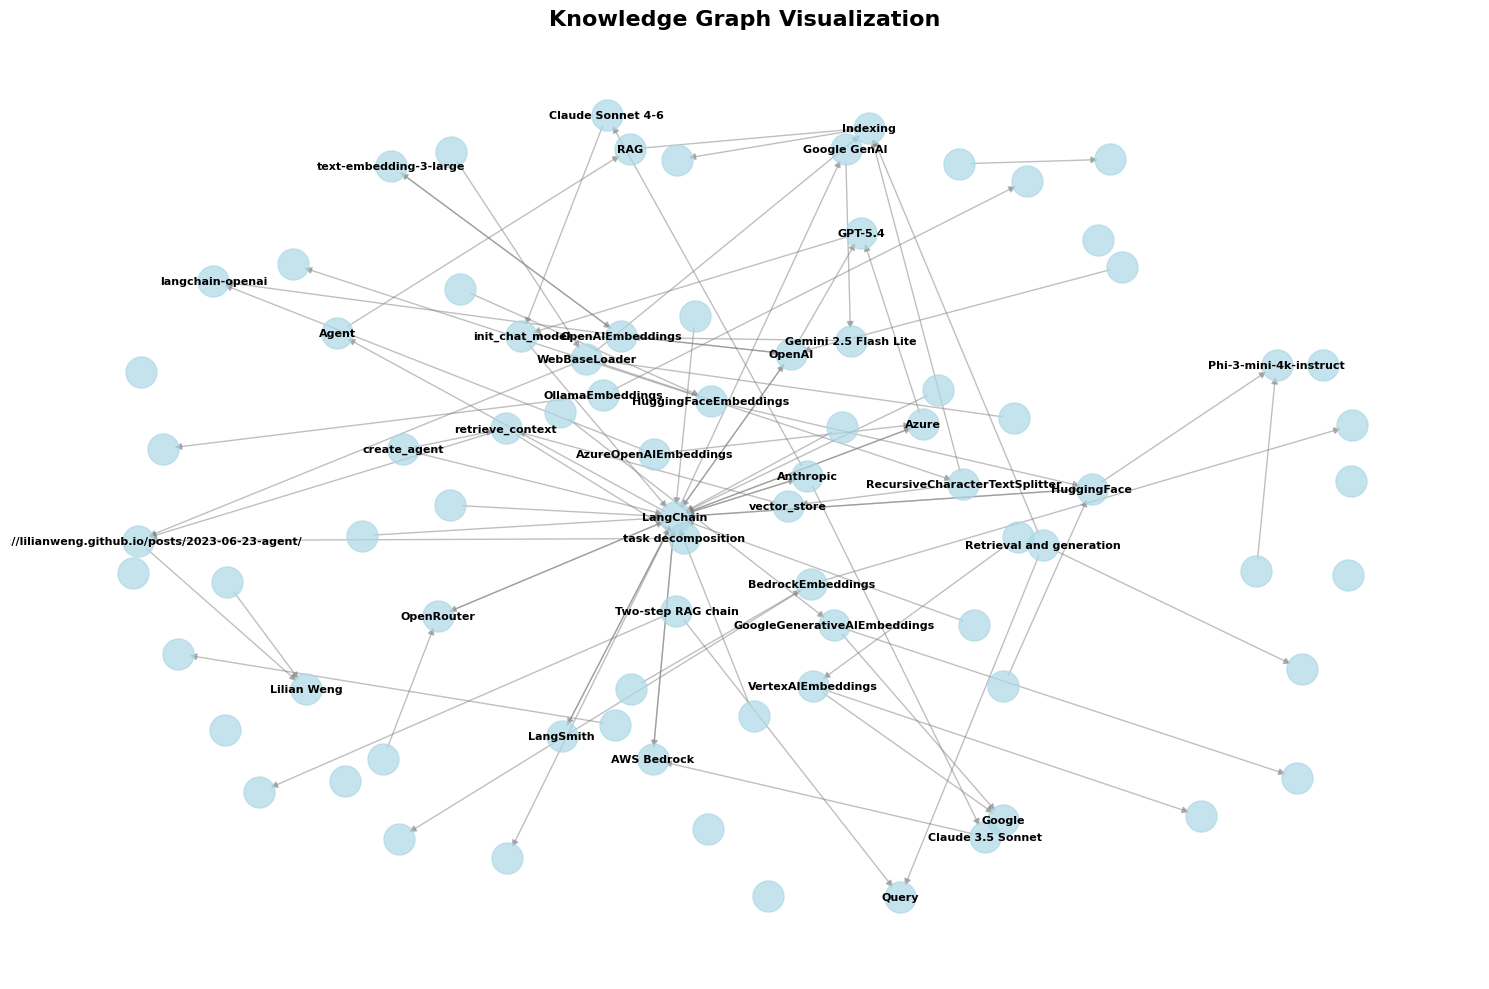


✓ Graph visualization complete

Note: Only high-degree nodes are labeled to reduce clutter


In [7]:
print_section_header("Visualizing Knowledge Graph")

# Create visualization
plt.figure(figsize=(15, 10))

# Use spring layout for better visualization
pos = nx.spring_layout(G, k=0.5, iterations=50)

# Draw nodes
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=500,
    node_color='lightblue',
    alpha=0.7,
)

# Draw edges
nx.draw_networkx_edges(
    G,
    pos,
    edge_color='gray',
    arrows=True,
    arrowsize=10,
    alpha=0.5,
)

# Draw labels (only for high-degree nodes to avoid clutter)
high_degree_nodes = [n for n, d in dict(G.degree).items() if d >= 2]
labels = {n: n for n in high_degree_nodes}
nx.draw_networkx_labels(
    G,
    pos,
    labels,
    font_size=8,
    font_weight='bold',
)

plt.title("Knowledge Graph Visualization", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print("\n✓ Graph visualization complete")
print("\nNote: Only high-degree nodes are labeled to reduce clutter")

## 7. 社区发现

使用 Louvain 算法识别相关实体簇。


In [8]:
print_section_header("Community Detection")

# Convert to undirected for community detection
G_undirected = G.to_undirected()

# Louvain community detection
try:
    import community as community_louvain
    
    communities = community_louvain.best_partition(G_undirected)
    
    # Group nodes by community
    community_groups = defaultdict(list)
    for node, comm_id in communities.items():
        community_groups[comm_id].append(node)
    
    print(f"\n✓ Found {len(community_groups)} communities")
    
    # Show community sizes
    print("\nCommunity sizes:")
    for comm_id, members in sorted(community_groups.items(), key=lambda x: len(x[1]), reverse=True):
        print(f"  • Community {comm_id}: {len(members)} entities")
        print(f"    Sample members: {', '.join(members[:5])}")
    
except ImportError:
    print("\n⚠️  python-louvain not installed. Skipping community detection.")
    print("   Install with: pip install python-louvain")
    communities = {}
    community_groups = {}


COMMUNITY DETECTION


✓ Found 20 communities

Community sizes:
  • Community 8: 19 entities
    Sample members: LangChain, RAG (Retrieval Augmented Generation), LangGraph, LangSmith, Interrupt
  • Community 4: 11 entities
    Sample members: Lilian Weng, LLM Powered Autonomous Agents blog post, WebBaseLoader, RecursiveCharacterTextSplitter, create_agent
  • Community 3: 9 entities
    Sample members: Two-step RAG chain, LLM, Query, Indexing, Retrieval and generation
  • Community 5: 8 entities
    Sample members: OpenAI, Azure, GPT-5.4, OpenAIEmbeddings, text-embedding-3-large
  • Community 6: 7 entities
    Sample members: HuggingFace, Microsoft, Phi-3-mini-4k-instruct, HUGGINGFACEHUB_API_TOKEN, HuggingFaceEmbeddings
  • Community 0: 7 entities
    Sample members: Google, GoogleGenerativeAIEmbeddings, VertexAIEmbeddings, models/gemini-embedding-001, text-embedding-005
  • Community 9: 4 entities
    Sample members: Amazon, BedrockEmbeddings, amazon.titan-embed-text-v2:0, langchain-aw

## 8. 创建图嵌入

为图节点建立向量表示，以便进行语义检索。


In [9]:
print_section_header("Creating Graph Embeddings")

# Create documents for each entity
entity_docs = []

for node in G.nodes():
    node_data = G.nodes[node]
    entity_type = node_data.get('type', 'UNKNOWN')
    description = node_data.get('description', '')
    
    # Get connected entities
    neighbors = list(G.neighbors(node))
    neighbors_str = ", ".join(neighbors[:5]) if neighbors else "none"
    
    # Create document
    content = f"{node} ({entity_type}): {description}\nConnected to: {neighbors_str}"
    
    # Get degree for this node (type: int)
    node_degree: int = G.degree(node)  # type: ignore
    
    doc = Document(
        page_content=content,
        metadata={
            "entity_name": node,
            "entity_type": entity_type,
            "description": description,
            "degree": node_degree,
        },
    )
    entity_docs.append(doc)

print(f"\n✓ Created {len(entity_docs)} entity documents")

# Create vector store
embeddings = create_embeddings()
entity_store_path = VECTOR_STORE_DIR / "graphrag_entities"

entity_vectorstore = load_vector_store(entity_store_path, embeddings)

if entity_vectorstore is None:
    print("\nCreating entity vector store...")
    entity_vectorstore = FAISS.from_documents(entity_docs, embeddings)
    save_vector_store(entity_vectorstore, entity_store_path)
    print("✓ Entity vector store created")
else:
    print("✓ Loaded existing entity vector store")

# Create retriever
entity_retriever = entity_vectorstore.as_retriever(search_kwargs={"k": 5})
print("✓ Entity retriever ready")


CREATING GRAPH EMBEDDINGS


✓ Created 82 entity documents


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Error loading vector store from D:\ZKS_Data\AI\langchain-rag-tutorial\data\vector_stores\graphrag_entities: Error in __cdecl faiss::FileIOReader::FileIOReader(const char *) at D:\a\faiss-wheels\faiss-wheels\third-party\faiss\faiss\impl\io.cpp:70: Error: 'f' failed: could not open D:\ZKS_Data\AI\langchain-rag-tutorial\data\vector_stores\graphrag_entities\index.faiss for reading: No such file or directory

Creating entity vector store...
Saved vector store to D:\ZKS_Data\AI\langchain-rag-tutorial\data\vector_stores\graphrag_entities
✓ Entity vector store created
✓ Entity retriever ready


## 9. 实现图遍历

在图中导航，找到与问题相关的子图。


In [10]:
def get_subgraph(
    G: nx.DiGraph,
    start_nodes: List[str],
    max_hops: int = 2,
    max_nodes: int = 20,
) -> nx.Graph:
    """
    Extract subgraph around starting nodes.
    
    Args:
        G: Full knowledge graph
        start_nodes: Starting entities
        max_hops: Maximum distance to traverse
        max_nodes: Maximum nodes in subgraph
    
    Returns:
        Subgraph
    """
    subgraph_nodes = set()
    
    # BFS from each start node
    for start in start_nodes:
        if start not in G:
            continue
        
        # Get nodes within max_hops
        for node in nx.single_source_shortest_path_length(
            G.to_undirected(),
            start,
            cutoff=max_hops,
        ).keys():
            subgraph_nodes.add(node)
            
            if len(subgraph_nodes) >= max_nodes:
                break
        
        if len(subgraph_nodes) >= max_nodes:
            break
    
    # Create subgraph
    return G.subgraph(subgraph_nodes).copy()


def subgraph_to_text(subgraph: nx.DiGraph) -> str:
    """
    Convert subgraph to text representation.
    """
    lines = []
    
    lines.append(f"Entities ({len(subgraph.nodes())}):")
    for node in list(subgraph.nodes())[:15]:
        node_data = subgraph.nodes[node]
        entity_type = node_data.get('type', 'UNKNOWN')
        description = node_data.get('description', '')[:100]
        lines.append(f"  • {node} ({entity_type}): {description}")
    
    lines.append(f"\nRelationships ({len(subgraph.edges())}):")
    for source, target in list(subgraph.edges())[:15]:
        edge_data = subgraph.edges[source, target]
        relation = edge_data.get('relation', 'related_to')
        lines.append(f"  • {source} --[{relation}]--> {target}")
    
    return "\n".join(lines)


print("✓ Graph traversal functions defined")

✓ Graph traversal functions defined


## 10. 构建 GraphRAG 查询流程


## 9b. 测试实体消歧

演示如何在查询阶段使用实体消歧。


In [11]:
print_section_header("Testing Entity Disambiguation")

# Example: Disambiguate entities for a query
test_query = "What is LangChain?"

# Get all entity names
all_entity_names = [e.get('name') for e in all_entities if e.get('name')]
entities_list = "\n".join([f"- {name}" for name in all_entity_names[:20]])  # Show first 20

print(f"Query: {test_query}\n")
print("Disambiguating relevant entities...")

# Use disambiguation prompt
disambiguation_chain = ENTITY_DISAMBIGUATION_PROMPT | llm | StrOutputParser()
relevant_entities_text = disambiguation_chain.invoke({
    "query": test_query,
    "entities": entities_list,
})

print("\nRelevant entities identified:")
print(relevant_entities_text)

print("\n✓ Entity disambiguation helps focus on query-relevant entities")


TESTING ENTITY DISAMBIGUATION

Query: What is LangChain?

Disambiguating relevant entities...

Relevant entities identified:
LangChain

✓ Entity disambiguation helps focus on query-relevant entities


In [12]:
def graphrag_query(
    question: str,
    G: nx.DiGraph,
    entity_retriever,
    llm,
    max_hops: int = 2,
    use_summarization: bool = True,
    verbose: bool = False,
) -> Dict[str, Any]:
    """
    GraphRAG query pipeline.
    
    Args:
        question: User question
        G: Knowledge graph
        entity_retriever: Entity retriever
        llm: Language model
        max_hops: Maximum graph traversal hops
        use_summarization: Use graph summarization for context
        verbose: Print debug info
    
    Returns:
        Query results
    """
    if verbose:
        print(f"\n[GraphRAG] Question: {question}")
    
    # 1. Retrieve relevant entities
    relevant_docs = entity_retriever.invoke(question)
    start_entities = [doc.metadata["entity_name"] for doc in relevant_docs]
    
    if verbose:
        print(f"[GraphRAG] Start entities: {', '.join(start_entities[:5])}")
    
    # 2. Extract subgraph
    subgraph = get_subgraph(G, start_entities, max_hops=max_hops)
    
    if verbose:
        print(f"[GraphRAG] Subgraph: {len(subgraph.nodes())} nodes, {len(subgraph.edges())} edges")
    
    # 3. Convert to text or summarize
    subgraph_text = subgraph_to_text(subgraph)
    
    if use_summarization and len(subgraph.nodes()) > 10:
        # Use summarization for larger subgraphs
        if verbose:
            print("[GraphRAG] Using graph summarization...")
        
        summary_chain = GRAPH_SUMMARIZATION_PROMPT | llm | StrOutputParser()
        context = summary_chain.invoke({"subgraph": subgraph_text})
        
        if verbose:
            print(f"[GraphRAG] Summarized context length: {len(context)} chars")
    else:
        context = subgraph_text
    
    # 4. Generate answer
    answer_chain = GRAPHRAG_ANSWER_PROMPT | llm | StrOutputParser()
    answer = answer_chain.invoke({
        "input": question,
        "context": context,
        "query_entities": ", ".join(start_entities[:5]),
        "num_hops": max_hops,
        "num_nodes": len(subgraph.nodes()),
    })
    
    return {
        "question": question,
        "start_entities": start_entities,
        "subgraph": subgraph,
        "context": context,
        "answer": answer,
        "used_summarization": use_summarization and len(subgraph.nodes()) > 10,
    }


print("✓ GraphRAG query pipeline defined")
print("✓ Pipeline now supports graph summarization for large subgraphs")

✓ GraphRAG query pipeline defined
✓ Pipeline now supports graph summarization for large subgraphs


## 11. 测试 GraphRAG


In [13]:
print_section_header("Testing GraphRAG")

test_questions = [
    "What is LangChain and what are its main components?",
    "How do chains work in LangChain?",
    "What role do retrievers play in RAG applications?",
]

for i, question in enumerate(test_questions, 1):
    print("\n" + "=" * 80)
    print(f"Question {i}: {question}")
    print("=" * 80)
    
    result = graphrag_query(
        question=question,
        G=G,
        entity_retriever=entity_retriever,
        llm=llm,
        max_hops=2,
        verbose=True,
    )
    
    print("\n" + "-" * 80)
    print("ANSWER:")
    print("-" * 80)
    print(result["answer"])


TESTING GRAPHRAG


Question 1: What is LangChain and what are its main components?

[GraphRAG] Question: What is LangChain and what are its main components?
[GraphRAG] Start entities: LangChain Academy, LangChain, init_chat_model, MessageLikeRepresentation, AgentState
[GraphRAG] Subgraph: 20 nodes, 26 edges
[GraphRAG] Using graph summarization...
[GraphRAG] Summarized context length: 1922 chars

--------------------------------------------------------------------------------
ANSWER:
--------------------------------------------------------------------------------
Based on the provided knowledge graph, **LangChain** is the central framework for building LLM (large language model) applications. Its main components include:

- **LangSmith** – a debugging and monitoring tool.
- **LangGraph** – a tool for building stateful, multi-actor agents.
- **LangChain Academy** – an educational resource.
- **Internal components** such as `MessageLikeRepresentation`, `AgentState`, and `create_agent`.
-

## 11b. 对比：使用摘要 vs 不使用摘要

对比原始子图上下文与摘要上下文的效果差异。


In [ ]:
print_section_header("Comparing Summarization Impact")

test_query = "What is LangChain and how does it work?"

print(f"Query: {test_query}\n")

print("=" * 80)

# Without summarization
print("\n[WITHOUT SUMMARIZATION]")
print("-" * 80)
result_no_sum = graphrag_query(
    question=test_query,
    G=G,
    entity_retriever=entity_retriever,
    llm=llm,
    max_hops=2,
    use_summarization=False,
    verbose=True,
)
print(f"\nContext length: {len(result_no_sum['context'])} chars")

# With summarization
print("\n" + "=" * 80)
print("\n[WITH SUMMARIZATION]")
print("-" * 80)
result_with_sum = graphrag_query(
    question=test_query,
    G=G,
    entity_retriever=entity_retriever,
    llm=llm,
    max_hops=2,
    use_summarization=True,
    verbose=True,
)
print(f"\nContext length: {len(result_with_sum['context'])} chars")
print(f"Used summarization: {result_with_sum['used_summarization']}")

# Compare
print("\n" + "=" * 80)
print("COMPARISON:")
print("=" * 80)
print(f"Without summarization: {len(result_no_sum['context'])} chars")
print(f"With summarization: {len(result_with_sum['context'])} chars")
if result_with_sum['used_summarization']:
    reduction = (1 - len(result_with_sum['context']) / len(result_no_sum['context'])) * 100
    print(f"Context reduction: {reduction:.1f}%")
    print("\n✅ Summarization helps compress large subgraphs while preserving key information")
else:
    print("\n⚠️  Subgraph too small for summarization (< 10 nodes)")


COMPARING SUMMARIZATION IMPACT

Query: What is LangChain and how does it work?


[WITHOUT SUMMARIZATION]
--------------------------------------------------------------------------------

[GraphRAG] Question: What is LangChain and how does it work?
[GraphRAG] Start entities: LangChain Academy, LangChain, init_chat_model, MessageLikeRepresentation, create_agent
[GraphRAG] Subgraph: 20 nodes, 26 edges

Context length: 2262 chars


[WITH SUMMARIZATION]
--------------------------------------------------------------------------------

[GraphRAG] Question: What is LangChain and how does it work?
[GraphRAG] Start entities: LangChain Academy, LangChain, init_chat_model, MessageLikeRepresentation, create_agent
[GraphRAG] Subgraph: 20 nodes, 26 edges
[GraphRAG] Using graph summarization...
[GraphRAG] Summarized context length: 2571 chars

Context length: 2571 chars
Used summarization: True

COMPARISON:
Without summarization: 2262 chars
With summarization: 2571 chars
Context reduction: -13.7%

✅ 

## 12. 可视化查询子图



VISUALIZING QUERY SUBGRAPH



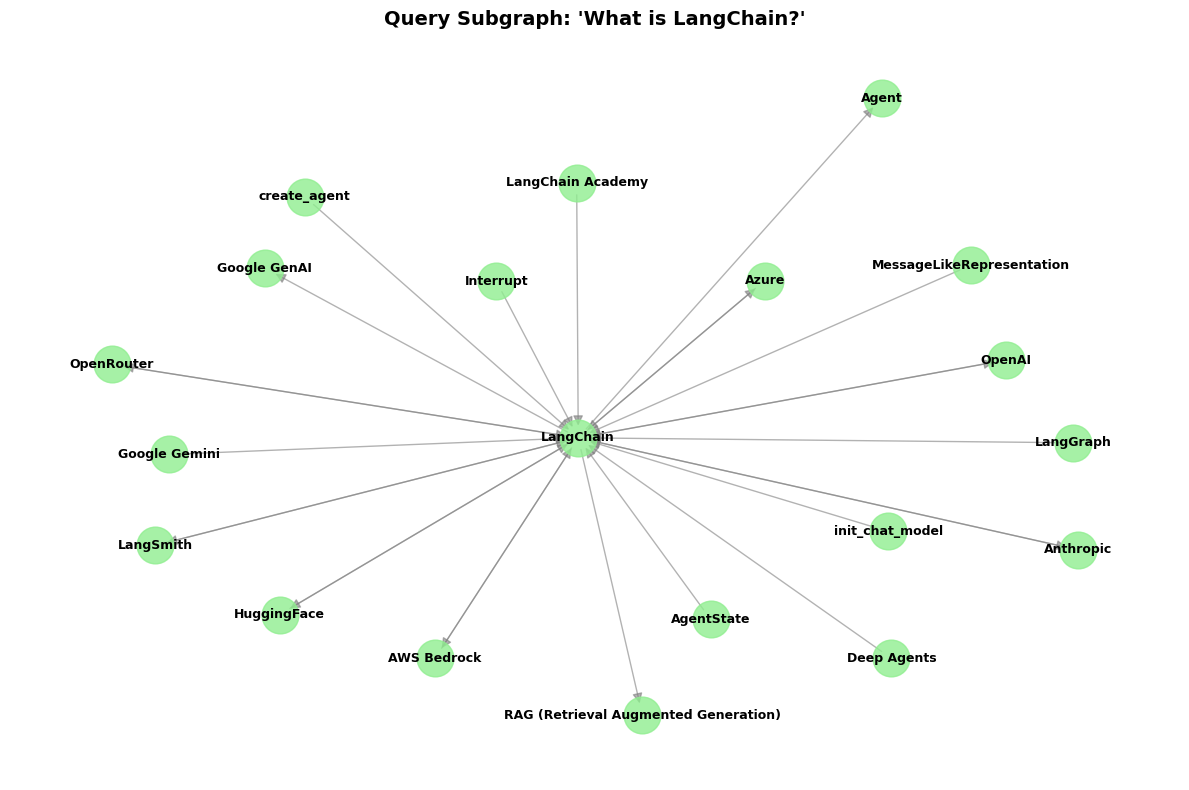


✓ Subgraph for query: 'What is LangChain?'
  • Nodes: 20
  • Edges: 26


In [15]:
print_section_header("Visualizing Query Subgraph")

# Get subgraph for a query
query = "What is LangChain?"
result = graphrag_query(
    question=query,
    G=G,
    entity_retriever=entity_retriever,
    llm=llm,
    verbose=False,
)

subgraph = result["subgraph"]

# Visualize
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(subgraph, k=1, iterations=50)

# Draw
nx.draw_networkx_nodes(subgraph, pos, node_size=700, node_color='lightgreen', alpha=0.8)
nx.draw_networkx_edges(subgraph, pos, edge_color='gray', arrows=True, arrowsize=15, alpha=0.6)
nx.draw_networkx_labels(subgraph, pos, font_size=9, font_weight='bold')

plt.title(f"Query Subgraph: '{query}'", fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"\n✓ Subgraph for query: '{query}'")
print(f"  • Nodes: {len(subgraph.nodes())}")
print(f"  • Edges: {len(subgraph.edges())}")

## 13. 对比：GraphRAG vs 向量 RAG


In [16]:
# Build simple vector RAG for comparison
from shared.prompts import RAG_PROMPT_TEMPLATE
from shared.utils import format_docs
from langchain_core.runnables import RunnablePassthrough

print_section_header("GraphRAG vs Vector RAG Comparison")

# Load vector store
vector_store_path = VECTOR_STORE_DIR / "graphrag_comparison"
vectorstore = load_vector_store(vector_store_path, embeddings)

if vectorstore is None:
    vectorstore = FAISS.from_documents(docs_sample, embeddings)
    save_vector_store(vectorstore, vector_store_path)

vector_retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

# Build vector RAG chain
vector_rag_chain = (
    {"context": vector_retriever | format_docs, "input": RunnablePassthrough()}
    | RAG_PROMPT_TEMPLATE
    | llm
    | StrOutputParser()
)

# Test query
test_query = "What are the relationships between LangChain components?"

print(f"\nQuery: {test_query}\n")
print("=" * 80)

# Vector RAG
print("\n[VECTOR RAG]")
print("-" * 80)
vector_answer = vector_rag_chain.invoke(test_query)
print(vector_answer)

# GraphRAG
print("\n" + "=" * 80)
print("\n[GRAPHRAG]")
print("-" * 80)
graph_result = graphrag_query(
    question=test_query,
    G=G,
    entity_retriever=entity_retriever,
    llm=llm,
    verbose=False,
)
print(graph_result["answer"])

# Comparison
print("\n" + "=" * 80)
print("ANALYSIS:")
print("=" * 80)
print("Vector RAG:")
print("  • Finds semantically similar documents")
print("  • Fast retrieval")
print("  • May miss relationship context")
print("\nGraphRAG:")
print("  • Understands entity relationships")
print("  • Multi-hop reasoning")
print("  • Explicit connection paths")
print("  • Better for 'how are X and Y related' queries")


GRAPHRAG VS VECTOR RAG COMPARISON

Error loading vector store from D:\ZKS_Data\AI\langchain-rag-tutorial\data\vector_stores\graphrag_comparison: Error in __cdecl faiss::FileIOReader::FileIOReader(const char *) at D:\a\faiss-wheels\faiss-wheels\third-party\faiss\faiss\impl\io.cpp:70: Error: 'f' failed: could not open D:\ZKS_Data\AI\langchain-rag-tutorial\data\vector_stores\graphrag_comparison\index.faiss for reading: No such file or directory
Saved vector store to D:\ZKS_Data\AI\langchain-rag-tutorial\data\vector_stores\graphrag_comparison

Query: What are the relationships between LangChain components?


[VECTOR RAG]
--------------------------------------------------------------------------------
Based on the context, the relationships between LangChain components in a RAG system are as follows:

1. **Indexing components** (Loading documents, Splitting documents, Storing documents) are used first to prepare the data for search.  
2. **Retrieval and generation** then use an **agent** a

## 14. 关键结论

### 总结

**GraphRAG** 把“检索相似文本”扩展为“理解实体与关系网络”。它的核心价值是：
- 将实体和关系作为一等公民
- 通过图遍历完成多跳推理
- 用社区摘要压缩大规模上下文
- 提供更强的可解释性

### 流程回顾

1. **实体抽取**：LLM 从文档中找出实体
2. **关系抽取**：LLM 识别实体之间的联系
3. **图构建**：用 NetworkX 构建知识图
4. **社区发现**：找出高关联的实体簇
5. **图嵌入**：为节点建立检索索引
6. **查询处理**：找到问题相关的起点实体
7. **图遍历**：抽取相关子图
8. **答案生成**：LLM 基于子图上下文生成回答

### 成本分析

| 阶段 | 成本 | 说明 |
|------|------|------|
| **索引构建** | 非常高 | 实体抽取 + 关系抽取需要大量 LLM 调用 |
| 实体抽取 | 高 | 每个文档至少 1 次调用 |
| 关系抽取 | 高 | 每个文档至少 1 次调用 |
| 图构建 | 低 | 本地计算为主 |
| **查询阶段** | 较低 | 通常只需 1 到 2 次 LLM 调用 |
| 实体检索 | 低 | 可以用向量索引完成 |
| 图遍历 | 低 | 主要是 NetworkX 运算 |
| 答案生成 | 中 | 最终综合上下文生成答案 |

### 最佳实践

**实体抽取：**
- 使用结构化输出（JSON）
- 保持实体类型一致
- 对同名或相似实体做消歧
- 对重复实体做合并

**关系抽取：**
- 使用有语义的关系类型
- 确认关系两端实体都存在
- 为关系增加置信度或说明

**图管理：**
- 限制子图大小
- 使用高效遍历算法
- 缓存高频子图
- 落地到图数据库（如 Neo4j）

### GraphRAG vs 向量 RAG

| 方面 | 向量 RAG | GraphRAG |
|--------|------------|----------|
| **索引速度** | 快 | 慢 |
| **索引成本** | 低 | 高 |
| **查询速度** | 快 | 快 |
| **存储开销** | 较低 | 更高 |
| **简单问题** | 很适合 | 2/5 可能过度设计 |
| **多跳推理** | 较弱 | 很强 |
| **关系表达** | 隐式 | 显式 |
| **可解释性** | 2/5 中等 | 高 |

### 何时选择 GraphRAG

适合 GraphRAG 的情况：
- 关系是核心信息
- 需要多跳推理
- 可以接受较高的一次性建索引成本
- 很看重可解释性
- 问题以实体为中心

继续使用向量 RAG 更合适的情况：
- 只需要简单文档检索
- 需要快速索引
- 对成本敏感
- 关系信息不是关键
- 语义相似度已经足够

### 生产环境考虑

- 可以使用 Neo4j 、Amazon Neptune 等图数据库
- 对实体和关系抽取做批处理
- 支持增量更新
- 缓存常用子图
- 引入人工审核、置信度评分和去重机制

---

**复杂度评级：** 5/5（非常高，属于 RAG 体系里最复杂的一类）

**生产就绪度：** 2/5（更偏实验性，落地需要额外投入）

**最适合：** 研究型场景、知识密集型应用，以及“关系比文档更重要”的任务。

继续阅读 **16_evaluation_ragas.ipynb**，了解更完整的 RAG 评估流程。


## 增强特性总结

当前 notebook 还包含以下 GraphRAG 增强能力：

### 1. **实体消歧**（第 3b 节）
- 对名称相似的实体进行去重
- 减少知识图谱中的冗余
- 使用 `ENTITY_DISAMBIGUATION_PROMPT` 做查询相关的筛选

### 2. **图摘要**（第 10 节和第 11b 节）
- 当子图较大时自动生成摘要
- 使用 `GRAPH_SUMMARIZATION_PROMPT` 压缩上下文
- 在保留关键信息的同时降低 LLM 上下文长度
- 可通过 `use_summarization` 参数开关

### 3. **一致的配置方式**
- 使用 `DEFAULT_TEMPERATURE` 获得更稳定、可复现的结果
- 所有 LLM 调用都走共享配置层

### 改进点
- **去重更好**：知识图更干净
- **扩展性更好**：能处理更大的子图
- **查询更灵活**：可在原始上下文和摘要上下文之间切换
- **行为更一致**：统一使用中心化配置

---
